In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
df = pd.read_csv("Fraud.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6362620
Number of columns: 11


In [7]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


In [8]:
print("DATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

DATA TYPES
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

MISSING VALUES
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [9]:
fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

print("\nFraud percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage:
isFraud
0   99.87
1    0.13
Name: proportion, dtype: float64


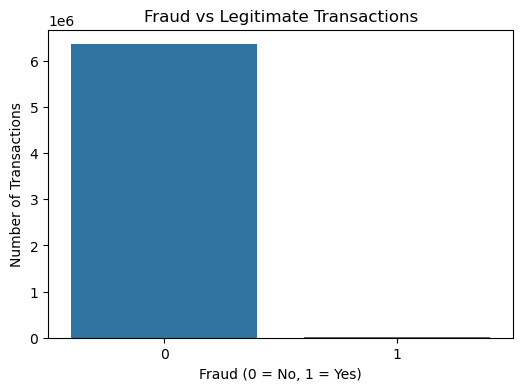

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="isFraud")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")

plt.show()

In [11]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

fraud_by_type.columns = ["Legitimate (%)", "Fraud (%)"]

fraud_by_type.sort_values(
    "Fraud (%)",
    ascending=False
)

,Legitimate (%),Fraud (%)
type,,
TRANSFER,99.23,0.77
CASH_OUT,99.82,0.18
CASH_IN,100.00,0.00
DEBIT,100.00,0.00
PAYMENT,100.00,0.00


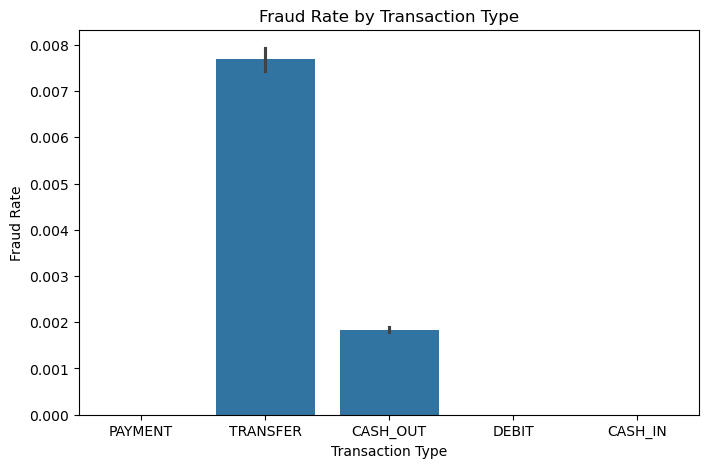

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="type",
    y="isFraud",
    estimator=np.mean
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")

plt.show()

In [15]:
print("Average transaction amount:")
print(df.groupby("isFraud")["amount"].mean())

print("\nMedian transaction amount:")
print(df.groupby("isFraud")["amount"].median())

print("\nMaximum transaction amount:")
print(df.groupby("isFraud")["amount"].max())

Average transaction amount:
isFraud
0     178,197.04
1   1,467,967.30
Name: amount, dtype: float64

Median transaction amount:
isFraud
0    74,684.72
1   441,423.44
Name: amount, dtype: float64

Maximum transaction amount:
isFraud
0   92,445,516.64
1   10,000,000.00
Name: amount, dtype: float64


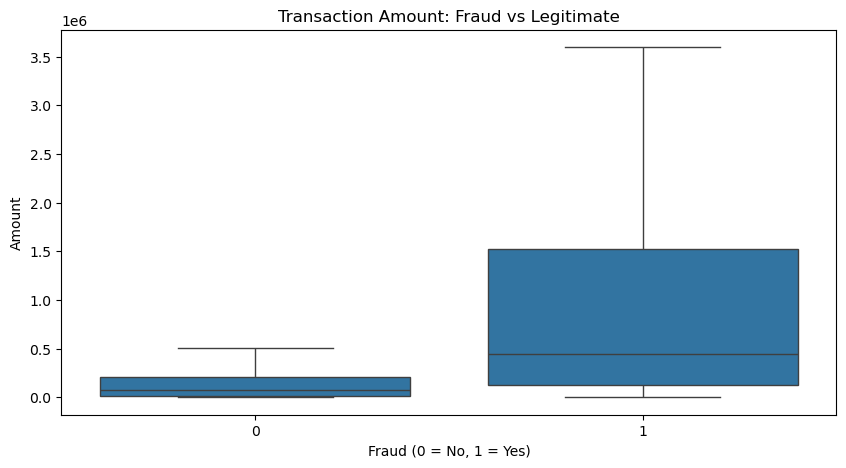

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount",
    showfliers=False
)

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Amount")

plt.show()

In [17]:
print(pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"],
    margins=True
))

isFlaggedFraud        0   1      All
isFraud                             
0               6354407   0  6354407
1                  8197  16     8213
All             6362604  16  6362620


In [18]:
print("Existing flagged fraud counts:")
print(df["isFlaggedFraud"].value_counts())

print("\nFraud rate among flagged transactions:")
print(
    df.loc[df["isFlaggedFraud"] == 1, "isFraud"].mean() * 100
)

Existing flagged fraud counts:
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

Fraud rate among flagged transactions:
100.0


In [19]:
type_summary = df.groupby("type").agg(
    transactions=("isFraud", "count"),
    fraud_transactions=("isFraud", "sum"),
    total_amount=("amount", "sum")
)

type_summary["fraud_rate_%"] = (
    type_summary["fraud_transactions"] /
    type_summary["transactions"] * 100
)

type_summary.sort_values(
    "fraud_rate_%",
    ascending=False
)

,transactions,fraud_transactions,total_amount,fraud_rate_%
type,,,,
TRANSFER,532909,4097,"485,291,987,263.17",0.77
CASH_OUT,2237500,4116,"394,412,995,224.49",0.18
CASH_IN,1399284,0,"236,367,391,912.46",0.00
DEBIT,41432,0,"227,199,221.28",0.00
PAYMENT,2151495,0,"28,093,371,138.37",0.00


In [20]:
fraud_by_step = df.groupby("step").agg(
    transactions=("isFraud", "count"),
    fraud_transactions=("isFraud", "sum"),
    total_amount=("amount", "sum")
)

fraud_by_step["fraud_rate_%"] = (
    fraud_by_step["fraud_transactions"] /
    fraud_by_step["transactions"] * 100
)

fraud_by_step.head()

,transactions,fraud_transactions,total_amount,fraud_rate_%
step,,,,
1,2708,16,"285,429,181.15",0.59
2,1014,8,"85,921,604.02",0.79
3,552,4,"43,293,884.42",0.72
4,565,10,"72,910,028.57",1.77
5,665,6,"45,548,089.75",0.90


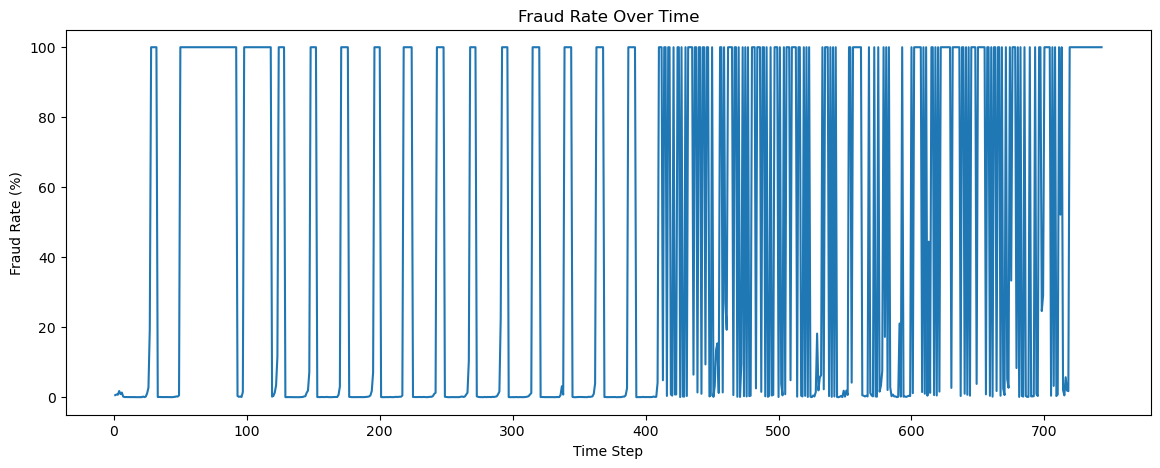

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(
    fraud_by_step.index,
    fraud_by_step["fraud_rate_%"]
)

plt.title("Fraud Rate Over Time")
plt.xlabel("Time Step")
plt.ylabel("Fraud Rate (%)")

plt.show()

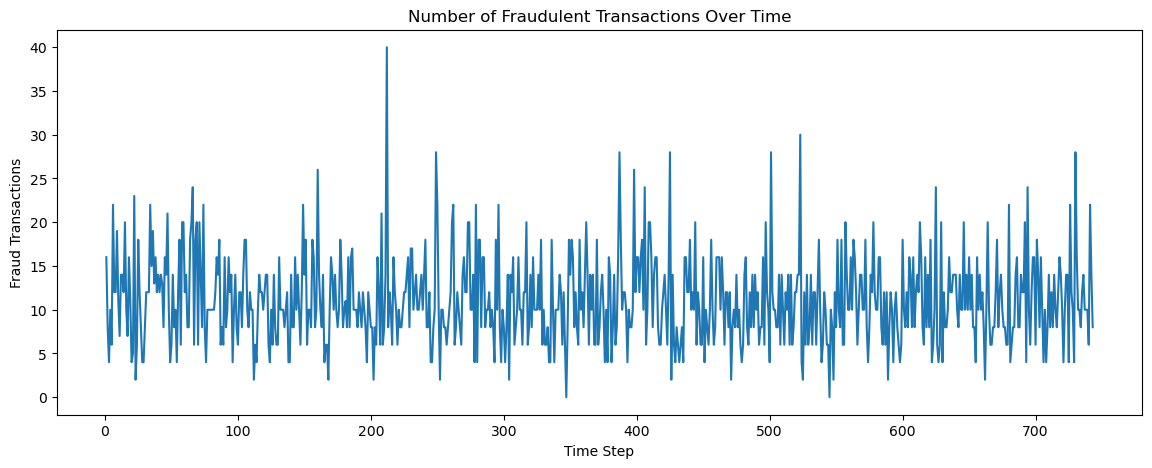

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(
    fraud_by_step.index,
    fraud_by_step["fraud_transactions"]
)

plt.title("Number of Fraudulent Transactions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Fraud Transactions")

plt.show()

In [23]:
df["origin_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

df["destination_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

In [24]:
print("Origin balance error:")
print(
    df.groupby("isFraud")["origin_balance_error"].describe()
)

print("\nDestination balance error:")
print(
    df.groupby("isFraud")["destination_balance_error"].describe()
)

Origin balance error:
               count        mean        std            min         25%  \
isFraud                                                                  
0       6,354,407.00 -201,338.56 606,928.89 -92,445,516.64 -249,953.43   
1           8,213.00  -10,692.33 265,146.13 -10,000,000.00        0.00   

               50%       75%  max  
isFraud                            
0       -69,049.31 -3,034.31 0.01  
1             0.00      0.00 0.00  

Destination balance error:
               count       mean          std            min  25%      50%  \
isFraud                                                                     
0       6,354,407.00  54,692.23   436,002.63 -75,885,725.63 0.00 3,500.68   
1           8,213.00 732,509.30 1,867,747.99  -8,875,516.29 0.00 2,231.46   

               75%           max  
isFraud                           
0        29,259.81 13,191,233.98  
1       442,722.01 10,000,000.00  


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df["isFraud"]
y_flagged = df["isFlaggedFraud"]

precision_flagged = precision_score(y_true, y_flagged, zero_division=0)
recall_flagged = recall_score(y_true, y_flagged, zero_division=0)
f1_flagged = f1_score(y_true, y_flagged, zero_division=0)

print("Existing Rule-Based System")
print("--------------------------")
print(f"Precision: {precision_flagged:.4f}")
print(f"Recall:    {recall_flagged:.4f}")
print(f"F1 Score:  {f1_flagged:.4f}")

Existing Rule-Based System
--------------------------
Precision: 1.0000
Recall:    0.0019
F1 Score:  0.0039


In [26]:
time_summary = df.groupby("step").agg(
    transactions=("isFraud", "count"),
    fraud_transactions=("isFraud", "sum"),
    fraud_amount=("amount", lambda x: x[df.loc[x.index, "isFraud"] == 1].sum())
)

time_summary["fraud_rate"] = (
    time_summary["fraud_transactions"] /
    time_summary["transactions"]
)

time_summary.head()

,transactions,fraud_transactions,fraud_amount,fraud_rate
step,,,,
1,2708,16,"3,740,247.01",0.01
2,1014,8,"4,186,592.48",0.01
3,552,4,"66,832.74",0.01
4,565,10,"26,400,274.90",0.02
5,665,6,"381,841.54",0.01


In [27]:
print("Total time steps:", df["step"].nunique())
print("First step:", df["step"].min())
print("Last step:", df["step"].max())

Total time steps: 743
First step: 1
Last step: 743


In [28]:
df["time_period"] = pd.qcut(
    df["step"],
    q=10,
    duplicates="drop"
)

period_summary = df.groupby("time_period", observed=True).agg(
    transactions=("isFraud", "count"),
    fraud_transactions=("isFraud", "sum")
)

period_summary["fraud_rate_%"] = (
    period_summary["fraud_transactions"] /
    period_summary["transactions"] * 100
)

period_summary

,transactions,fraud_transactions,fraud_rate_%
time_period,,,
"(0.999, 35.0]",660051,398,0.06
"(35.0, 135.0]",632404,1148,0.18
"(135.0, 166.0]",625955,350,0.06
"(166.0, 206.0]",650042,410,0.06
"(206.0, 239.0]",618040,399,0.06
"(239.0, 281.0]",634107,488,0.08
"(281.0, 323.0]",642988,450,0.07
"(323.0, 355.0]",650297,320,0.05
"(355.0, 399.0]",642236,498,0.08


In [30]:
df["amount_bucket"] = pd.qcut(
    df["amount"],
    q=10,
    duplicates="drop"
)

amount_summary = df.groupby(
    "amount_bucket",
    observed=True
).agg(
    transactions=("isFraud", "count"),
    fraud_transactions=("isFraud", "sum")
)

amount_summary["fraud_rate_%"] = (
    amount_summary["fraud_transactions"] /
    amount_summary["transactions"] * 100
)

amount_summary

,transactions,fraud_transactions,fraud_rate_%
amount_bucket,,,
"(-0.001, 4501.3]",636263,148,0.02
"(4501.3, 9866.158]",636261,128,0.02
"(9866.158, 18092.028]",636262,148,0.02
"(18092.028, 36371.35]",636262,365,0.06
"(36371.35, 74871.94]",636262,617,0.10
"(74871.94, 122563.784]",636262,592,0.09
"(122563.784, 176801.919]",636262,581,0.09
"(176801.919, 246611.22]",636262,503,0.08
"(246611.22, 365423.309]",636262,719,0.11


In [32]:
df["origin_balance_error"]


0         0.00
1         0.00
2         0.00
3         0.00
4         0.00
          ... 
6362615   0.00
6362616   0.00
6362617   0.00
6362618   0.00
6362619   0.00
Name: origin_balance_error, Length: 6362620, dtype: float64

In [33]:
df["destination_balance_error"]

0             9,839.64
1             1,864.28
2               181.00
3            21,363.00
4            11,668.14
              ...     
6362615           0.00
6362616   6,311,409.28
6362617           0.01
6362618     850,002.52
6362619           0.00
Name: destination_balance_error, Length: 6362620, dtype: float64

In [34]:
df["time_period"]

0           (0.999, 35.0]
1           (0.999, 35.0]
2           (0.999, 35.0]
3           (0.999, 35.0]
4           (0.999, 35.0]
                ...      
6362615    (399.0, 743.0]
6362616    (399.0, 743.0]
6362617    (399.0, 743.0]
6362618    (399.0, 743.0]
6362619    (399.0, 743.0]
Name: time_period, Length: 6362620, dtype: category
Categories (10, interval[float64, right]): [(0.999, 35.0] < (35.0, 135.0] < (135.0, 166.0] < (166.0, 206.0] ... (281.0, 323.0] < (323.0, 355.0] < (355.0, 399.0] < (399.0, 743.0]]

In [35]:
df["amount_bucket"]

0                 (4501.3, 9866.158]
1                   (-0.001, 4501.3]
2                   (-0.001, 4501.3]
3                   (-0.001, 4501.3]
4              (9866.158, 18092.028]
                     ...            
6362615      (246611.22, 365423.309]
6362616    (365423.309, 92445516.64]
6362617    (365423.309, 92445516.64]
6362618    (365423.309, 92445516.64]
6362619    (365423.309, 92445516.64]
Name: amount_bucket, Length: 6362620, dtype: category
Categories (10, interval[float64, right]): [(-0.001, 4501.3] < (4501.3, 9866.158] < (9866.158, 18092.028] < (18092.028, 36371.35] ... (122563.784, 176801.919] < (176801.919, 246611.22] < (246611.22, 365423.309] < (365423.309, 92445516.64]]

In [36]:
df.drop(
    columns=["time_period", "amount_bucket"],
    inplace=True
)

print(df.shape)

(6362620, 13)


In [37]:
print(df["type"].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [38]:
print("\nFraud transactions by type:")
print(
    df[df["isFraud"] == 1]["type"].value_counts()
)


Fraud transactions by type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


In [39]:
model_df = df[
    [
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "isFraud"
    ]
].copy()

print(model_df.shape)
display(model_df.head())

(6362620, 6)


,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud
0,1,PAYMENT,"9,839.64","170,136.00",0.00,0
1,1,PAYMENT,"1,864.28","21,249.00",0.00,0
2,1,TRANSFER,181.00,181.00,0.00,1
3,1,CASH_OUT,181.00,181.00,"21,182.00",1
4,1,PAYMENT,"11,668.14","41,554.00",0.00,0


In [40]:
model_df["log_amount"] = np.log1p(model_df["amount"])

model_df["amount_to_origin_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceOrg"] + 1)
)

model_df["amount_to_destination_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceDest"] + 1)
)

model_df["origin_balance_zero"] = (
    model_df["oldbalanceOrg"] == 0
).astype(int)

model_df["destination_balance_zero"] = (
    model_df["oldbalanceDest"] == 0
).astype(int)

In [41]:
display(
    model_df.head()
)

,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,log_amount,amount_to_origin_balance,amount_to_destination_balance,origin_balance_zero,destination_balance_zero
0,1,PAYMENT,"9,839.64","170,136.00",0.00,0,9.19,0.06,"9,839.64",0,1
1,1,PAYMENT,"1,864.28","21,249.00",0.00,0,7.53,0.09,"1,864.28",0,1
2,1,TRANSFER,181.00,181.00,0.00,1,5.20,0.99,181.00,0,1
3,1,CASH_OUT,181.00,181.00,"21,182.00",1,5.20,0.99,0.01,0,0
4,1,PAYMENT,"11,668.14","41,554.00",0.00,0,9.36,0.28,"11,668.14",0,1


In [42]:
print(model_df["type"].unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


In [43]:
model_df = pd.get_dummies(
    model_df,
    columns=["type"],
    dtype=int
)

display(model_df.head())

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,log_amount,amount_to_origin_balance,amount_to_destination_balance,origin_balance_zero,destination_balance_zero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,"9,839.64","170,136.00",0.00,0,9.19,0.06,"9,839.64",0,1,0,0,0,1,0
1,1,"1,864.28","21,249.00",0.00,0,7.53,0.09,"1,864.28",0,1,0,0,0,1,0
2,1,181.00,181.00,0.00,1,5.20,0.99,181.00,0,1,0,0,0,0,1
3,1,181.00,181.00,"21,182.00",1,5.20,0.99,0.01,0,0,0,1,0,0,0
4,1,"11,668.14","41,554.00",0.00,0,9.36,0.28,"11,668.14",0,1,0,0,0,1,0


In [44]:
print("Total steps:", df["step"].nunique())

print("\nStep quantiles:")
print(
    df["step"].quantile(
        [0.70, 0.75, 0.80, 0.85, 0.90]
    )
)

Total steps: 743

Step quantiles:
0.70   323.00
0.75   335.00
0.80   355.00
0.85   378.00
0.90   399.00
Name: step, dtype: float64


In [45]:
for step in [500, 550, 600, 650, 700]:
    subset = df[df["step"] <= step]

    print(
        f"Step <= {step}: "
        f"{len(subset):,} transactions | "
        f"{subset['isFraud'].sum():,} frauds"
    )

Step <= 500: 6,061,807 transactions | 5,561 frauds
Step <= 550: 6,166,019 transactions | 6,065 frauds
Step <= 600: 6,259,047 transactions | 6,613 frauds
Step <= 650: 6,281,789 transactions | 7,191 frauds
Step <= 700: 6,351,199 transactions | 7,723 frauds


In [46]:
model_df["amount_to_origin_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceOrg"] + 1)
).clip(upper=10)

model_df["amount_to_destination_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceDest"] + 1)
).clip(upper=10)

print(model_df[
    [
        "amount_to_origin_balance",
        "amount_to_destination_balance"
    ]
].describe())

       amount_to_origin_balance  amount_to_destination_balance
count              6,362,620.00                   6,362,620.00
mean                       5.43                           4.68
std                        4.59                           4.77
min                        0.00                           0.00
25%                        0.23                           0.16
50%                        6.45                           0.92
75%                       10.00                          10.00
max                       10.00                          10.00


In [47]:
train_df = model_df[model_df["step"] <= 500].copy()

val_df = model_df[
    (model_df["step"] > 500) &
    (model_df["step"] <= 600)
].copy()

test_df = model_df[
    model_df["step"] > 600
].copy()

print("TRAIN")
print("Rows:", len(train_df))
print("Fraud:", train_df["isFraud"].sum())
print("Fraud rate:", train_df["isFraud"].mean() * 100)

print("\nVALIDATION")
print("Rows:", len(val_df))
print("Fraud:", val_df["isFraud"].sum())
print("Fraud rate:", val_df["isFraud"].mean() * 100)

print("\nTEST")
print("Rows:", len(test_df))
print("Fraud:", test_df["isFraud"].sum())
print("Fraud rate:", test_df["isFraud"].mean() * 100)

TRAIN
Rows: 6061807
Fraud: 5561
Fraud rate: 0.09173832159288477

VALIDATION
Rows: 197240
Fraud: 1052
Fraud rate: 0.5333603731494625

TEST
Rows: 103573
Fraud: 1600
Fraud rate: 1.5448041477991368


In [48]:
X_train = train_df.drop(columns=["isFraud"])
y_train = train_df["isFraud"]

X_val = val_df.drop(columns=["isFraud"])
y_val = val_df["isFraud"]

X_test = test_df.drop(columns=["isFraud"])
y_test = test_df["isFraud"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (6061807, 14)
X_val: (197240, 14)
X_test: (103573, 14)


In [49]:
import sklearn

print("scikit-learn:", sklearn.__version__)

try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except ImportError:
    print("XGBoost: NOT INSTALLED")

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except ImportError:
    print("LightGBM: NOT INSTALLED")

scikit-learn: 1.5.1
XGBoost: NOT INSTALLED
LightGBM: NOT INSTALLED


In [50]:
print("Feature columns:")
print(X_train.columns.tolist())

print("\nData types:")
print(X_train.dtypes)

print("\nMissing values:")
print(X_train.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())

Feature columns:
['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'log_amount', 'amount_to_origin_balance', 'amount_to_destination_balance', 'origin_balance_zero', 'destination_balance_zero', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Data types:
step                               int64
amount                           float64
oldbalanceOrg                    float64
oldbalanceDest                   float64
log_amount                       float64
amount_to_origin_balance         float64
amount_to_destination_balance    float64
origin_balance_zero                int32
destination_balance_zero           int32
type_CASH_IN                       int32
type_CASH_OUT                      int32
type_DEBIT                         int32
type_PAYMENT                       int32
type_TRANSFER                      int32
dtype: object

Missing values:
0

Infinite values:
0


In [51]:
fraud_train = train_df[train_df["isFraud"] == 1]

legit_train = train_df[train_df["isFraud"] == 0].sample(
    n=300_000,
    random_state=42
)

train_sample = pd.concat(
    [fraud_train, legit_train]
).sample(
    frac=1,
    random_state=42
)

print("Training sample shape:", train_sample.shape)
print("Fraud:", train_sample["isFraud"].sum())
print("Legitimate:", (train_sample["isFraud"] == 0).sum())
print("Fraud rate:", train_sample["isFraud"].mean() * 100)

Training sample shape: (305561, 15)
Fraud: 5561
Legitimate: 300000
Fraud rate: 1.8199312084984667


In [52]:
X_train_sample = train_sample.drop(columns=["isFraud"])
y_train_sample = train_sample["isFraud"]

print(X_train_sample.shape)
print(y_train_sample.value_counts())

(305561, 14)
isFraud
0    300000
1      5561
Name: count, dtype: int64


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sample)
X_val_scaled = scaler.transform(X_val)

print("Scaling complete.")

Scaling complete.


In [54]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=200,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train_sample
)

print("Logistic Regression trained.")

Logistic Regression trained.


In [55]:
val_prob_logistic = logistic_model.predict_proba(
    X_val_scaled
)[:, 1]

print("Minimum risk score:", val_prob_logistic.min())
print("Maximum risk score:", val_prob_logistic.max())
print("Average risk score:", val_prob_logistic.mean())

Minimum risk score: 2.717268064173053e-23
Maximum risk score: 1.0
Average risk score: 0.07653128798190922


In [56]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

results = []

for threshold in thresholds:

    y_pred = (
        val_prob_logistic >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1,false_positives,false_negatives
0,0.10,0.05,1.00,0.10,19479,1
1,0.20,0.06,1.00,0.11,17822,1
2,0.30,0.06,1.00,0.11,16657,1
3,0.40,0.06,1.00,0.12,15533,1
4,0.50,0.07,1.00,0.13,14339,1
5,0.60,0.07,0.98,0.14,13104,16
6,0.70,0.08,0.96,0.15,11535,41
7,0.80,0.09,0.88,0.17,9187,123
8,0.90,0.15,0.79,0.26,4631,218


In [57]:
val_amount = val_df["amount"].values

cost_results = []

for threshold in thresholds:

    y_pred = (
        val_prob_logistic >= threshold
    ).astype(int)

    false_negative_mask = (
        (y_val.values == 1) &
        (y_pred == 0)
    )

    false_positive_mask = (
        (y_val.values == 0) &
        (y_pred == 1)
    )

    missed_fraud_amount = (
        val_amount[false_negative_mask].sum()
    )

    false_positive_amount = (
        val_amount[false_positive_mask].sum()
    )

    false_positive_cost = (
        false_positive_amount * 0.01
    )

    total_cost = (
        missed_fraud_amount +
        false_positive_cost
    )

    cost_results.append({
        "threshold": threshold,
        "missed_fraud_amount": missed_fraud_amount,
        "false_positive_cost": false_positive_cost,
        "total_cost": total_cost
    })

cost_df = pd.DataFrame(cost_results)

cost_df

,threshold,missed_fraud_amount,false_positive_cost,total_cost
0,0.10,"495,977.84","32,939,841.53","33,435,819.37"
1,0.20,"495,977.84","24,154,177.57","24,650,155.41"
2,0.30,"495,977.84","21,694,726.06","22,190,703.90"
3,0.40,"495,977.84","19,770,267.97","20,266,245.81"
4,0.50,"495,977.84","17,892,174.47","18,388,152.31"
5,0.60,"539,935.75","15,920,203.98","16,460,139.73"
6,0.70,"1,190,263.84","13,535,786.52","14,726,050.36"
7,0.80,"11,343,240.46","10,490,243.84","21,833,484.30"
8,0.90,"42,069,441.34","5,822,360.90","47,891,802.24"


In [58]:
# Create additional transaction-time features

model_df["sender_remaining_balance"] = (
    model_df["oldbalanceOrg"] - model_df["amount"]
)

model_df["amount_to_sender_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceOrg"] + 1)
).clip(upper=10)

model_df["amount_log"] = np.log1p(model_df["amount"])

model_df["is_large_transaction"] = (
    model_df["amount"] > 100000
).astype(int)

model_df["is_transfer_or_cashout"] = (
    model_df["type_TRANSFER"] +
    model_df["type_CASH_OUT"]
).clip(upper=1)

print(model_df.shape)

display(
    model_df[
        [
            "amount",
            "oldbalanceOrg",
            "sender_remaining_balance",
            "amount_to_sender_balance",
            "amount_log",
            "is_large_transaction",
            "is_transfer_or_cashout"
        ]
    ].head()
)

(6362620, 20)


,amount,oldbalanceOrg,sender_remaining_balance,amount_to_sender_balance,amount_log,is_large_transaction,is_transfer_or_cashout
0,"9,839.64","170,136.00","160,296.36",0.06,9.19,0,0
1,"1,864.28","21,249.00","19,384.72",0.09,7.53,0,0
2,181.00,181.00,0.00,0.99,5.20,0,1
3,181.00,181.00,0.00,0.99,5.20,0,1
4,"11,668.14","41,554.00","29,885.86",0.28,9.36,0,0


In [59]:
train_df = model_df[
    model_df["step"] <= 500
].copy()

val_df = model_df[
    (model_df["step"] > 500) &
    (model_df["step"] <= 600)
].copy()

test_df = model_df[
    model_df["step"] > 600
].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (6061807, 20)
Validation: (197240, 20)
Test: (103573, 20)


In [60]:
fraud_train = train_df[
    train_df["isFraud"] == 1
]

legit_train = train_df[
    train_df["isFraud"] == 0
].sample(
    n=300_000,
    random_state=42
)

train_sample = pd.concat(
    [fraud_train, legit_train]
).sample(
    frac=1,
    random_state=42
)

print("Training sample:", train_sample.shape)
print(train_sample["isFraud"].value_counts())

Training sample: (305561, 20)
isFraud
0    300000
1      5561
Name: count, dtype: int64


In [61]:
X_train_sample = train_sample.drop(
    columns=["isFraud"]
)

y_train_sample = train_sample["isFraud"]

X_val = val_df.drop(
    columns=["isFraud"]
)

y_val = val_df["isFraud"]

X_test = test_df.drop(
    columns=["isFraud"]
)

y_test = test_df["isFraud"]

print("X_train:", X_train_sample.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (305561, 19)
X_val: (197240, 19)
X_test: (103573, 19)


In [62]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42
)

gb_model.fit(
    X_train_sample,
    y_train_sample
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [63]:
val_prob_gb = gb_model.predict_proba(
    X_val
)[:, 1]

print("Minimum risk score:", val_prob_gb.min())
print("Maximum risk score:", val_prob_gb.max())
print("Average risk score:", val_prob_gb.mean())

Minimum risk score: 6.453443567557511e-05
Maximum risk score: 0.999937968736634
Average risk score: 0.005421176916054947


In [64]:
thresholds = [
    0.10, 0.20, 0.30, 0.40,
    0.50, 0.60, 0.70, 0.80, 0.90
]

gb_results = []

for threshold in thresholds:

    y_pred = (
        val_prob_gb >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    gb_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": fp,
        "false_negatives": fn
    })

gb_threshold_results = pd.DataFrame(
    gb_results
)

display(gb_threshold_results)

,threshold,precision,recall,f1,false_positives,false_negatives
0,0.10,1.00,1.00,1.00,1,0
1,0.20,1.00,1.00,1.00,1,0
2,0.30,1.00,1.00,1.00,1,0
3,0.40,1.00,1.00,1.00,1,0
4,0.50,1.00,1.00,1.00,1,0
5,0.60,1.00,1.00,1.00,1,0
6,0.70,1.00,1.00,1.00,1,0
7,0.80,1.00,1.00,1.00,1,0
8,0.90,1.00,1.00,1.00,1,0


In [65]:
val_amount = val_df["amount"].values

gb_cost_results = []

for threshold in thresholds:

    y_pred = (
        val_prob_gb >= threshold
    ).astype(int)

    false_negative_mask = (
        (y_val.values == 1) &
        (y_pred == 0)
    )

    false_positive_mask = (
        (y_val.values == 0) &
        (y_pred == 1)
    )

    missed_fraud_amount = (
        val_amount[false_negative_mask].sum()
    )

    false_positive_amount = (
        val_amount[false_positive_mask].sum()
    )

    false_positive_cost = (
        false_positive_amount * 0.01
    )

    total_cost = (
        missed_fraud_amount +
        false_positive_cost
    )

    gb_cost_results.append({
        "threshold": threshold,
        "missed_fraud_amount": missed_fraud_amount,
        "false_positive_cost": false_positive_cost,
        "total_cost": total_cost
    })

gb_cost_df = pd.DataFrame(
    gb_cost_results
)

display(gb_cost_df)

,threshold,missed_fraud_amount,false_positive_cost,total_cost
0,0.10,0.00,"2,538.05","2,538.05"
1,0.20,0.00,"2,538.05","2,538.05"
2,0.30,0.00,"2,538.05","2,538.05"
3,0.40,0.00,"2,538.05","2,538.05"
4,0.50,0.00,"2,538.05","2,538.05"
5,0.60,0.00,"2,538.05","2,538.05"
6,0.70,0.00,"2,538.05","2,538.05"
7,0.80,0.00,"2,538.05","2,538.05"
8,0.90,0.00,"2,538.05","2,538.05"


In [68]:
print("LEGITIMATE RISK SCORE DISTRIBUTION")
print(
    pd.Series(
        val_prob_gb[y_val.values == 0]
    ).describe(
        percentiles=[0.90, 0.95, 0.99, 0.999]
    )
)

print("\nFRAUD RISK SCORE DISTRIBUTION")
print(
    pd.Series(
        val_prob_gb[y_val.values == 1]
    ).describe(
        percentiles=[0.01, 0.05, 0.10, 0.50]
    )
)

LEGITIMATE RISK SCORE DISTRIBUTION
count   196,188.00
mean          0.00
std           0.00
min           0.00
50%           0.00
90%           0.00
95%           0.00
99%           0.00
99.9%         0.00
max           1.00
dtype: float64

FRAUD RISK SCORE DISTRIBUTION
count   1,052.00
mean        1.00
std         0.00
min         1.00
1%          1.00
5%          1.00
10%         1.00
50%         1.00
max         1.00
dtype: float64


In [69]:
print("\nLowest fraud scores:")
print(
    np.sort(
        val_prob_gb[y_val.values == 1]
    )[:20]
)

print("\nHighest legitimate scores:")
print(
    np.sort(
        val_prob_gb[y_val.values == 0]
    )[-20:]
)


Lowest fraud scores:
[0.99968179 0.99968179 0.99968179 0.99968179 0.99968179 0.99968179
 0.99968179 0.99968179 0.99968179 0.99968179 0.9997105  0.9997105
 0.9997105  0.9997105  0.99988238 0.99988238 0.99988238 0.99988238
 0.99988238 0.99988238]

Highest legitimate scores:
[0.052872   0.052872   0.052872   0.052872   0.052872   0.052872
 0.052872   0.052872   0.052872   0.052872   0.052872   0.052872
 0.052872   0.052872   0.052872   0.052872   0.052872   0.052872
 0.052872   0.99988238]


In [70]:
feature_analysis = []

for col in X_train_sample.columns:

    legit_mean = train_sample.loc[
        train_sample["isFraud"] == 0, col
    ].mean()

    fraud_mean = train_sample.loc[
        train_sample["isFraud"] == 1, col
    ].mean()

    feature_analysis.append({
        "feature": col,
        "legitimate_mean": legit_mean,
        "fraud_mean": fraud_mean,
        "absolute_difference": abs(
            fraud_mean - legit_mean
        )
    })

feature_analysis_df = (
    pd.DataFrame(feature_analysis)
    .sort_values(
        "absolute_difference",
        ascending=False
    )
)

display(feature_analysis_df)

,feature,legitimate_mean,fraud_mean,absolute_difference
1,amount,"178,952.87","1,441,409.40","1,262,456.53"
2,oldbalanceOrg,"843,361.02","1,575,986.72","732,625.70"
3,oldbalanceDest,"1,095,347.64","491,667.01","603,680.63"
14,sender_remaining_balance,"664,408.15","134,577.32","529,830.83"
0,step,225.71,246.72,21.01
5,amount_to_origin_balance,5.44,1.04,4.40
15,amount_to_sender_balance,5.44,1.04,4.40
6,amount_to_destination_balance,4.67,7.61,2.94
4,log_amount,10.84,12.89,2.05
16,amount_log,10.84,12.89,2.05


In [71]:
fraud_patterns = df.groupby("isFraud")[
    [
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest"
    ]
].mean()

display(fraud_patterns)

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,,
0,"178,197.04","832,828.71","855,970.23","1,101,420.87","1,224,925.68"
1,"1,467,967.30","1,649,667.61","192,392.63","544,249.62","1,279,707.62"


In [72]:
fraud_type_pattern = pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

display(fraud_type_pattern)

isFraud,0,1
type,,
CASH_IN,100.00,0.00
CASH_OUT,99.82,0.18
DEBIT,100.00,0.00
PAYMENT,100.00,0.00
TRANSFER,99.23,0.77


In [73]:
# ============================================================
# AI RISK MANAGER — MODEL 2
# Lock the selected Gradient Boosting model
# ============================================================

final_model = gb_model

print("Selected Model: Gradient Boosting Classifier")
print("Model is now locked for final evaluation.")

Selected Model: Gradient Boosting Classifier
Model is now locked for final evaluation.


In [74]:
# ============================================================
# VALIDATION RISK SCORES
# ============================================================

val_prob = final_model.predict_proba(X_val)[:, 1]

print("Validation transactions:", len(val_prob))
print("Minimum risk score:", val_prob.min())
print("Maximum risk score:", val_prob.max())
print("Average risk score:", val_prob.mean())

Validation transactions: 197240
Minimum risk score: 6.453443567557511e-05
Maximum risk score: 0.999937968736634
Average risk score: 0.005421176916054947


In [75]:
RISK_THRESHOLD = 0.70

print("Selected operational threshold:", RISK_THRESHOLD)

Selected operational threshold: 0.7


In [76]:
# ============================================================
# AI RISK DECISION ENGINE
# ============================================================

RISK_THRESHOLD = 0.70

def calculate_risk(model, X):
    """
    Generate fraud probability / risk score.
    """
    return model.predict_proba(X)[:, 1]


def make_decision(risk_score, threshold=RISK_THRESHOLD):
    """
    Convert risk probability into an operational decision.
    """

    if risk_score >= threshold:
        return "BLOCK / INVESTIGATE"
    else:
        return "APPROVE"


def risk_level(risk_score):
    """
    Convert probability into human-readable risk levels.
    """

    if risk_score < 0.20:
        return "LOW"
    elif risk_score < 0.50:
        return "MEDIUM"
    elif risk_score < 0.70:
        return "HIGH"
    else:
        return "CRITICAL"

In [77]:
# ============================================================
# TRANSACTION RISK SCORING
# ============================================================

def score_transactions(model, X):

    scores = calculate_risk(model, X)

    results = pd.DataFrame({
        "risk_score": scores
    })

    results["risk_level"] = results["risk_score"].apply(risk_level)

    results["decision"] = results["risk_score"].apply(
        make_decision
    )

    return results

In [78]:
val_results = score_transactions(
    final_model,
    X_val
)

display(val_results.head(10))

,risk_score,risk_level,decision
0,1.00,CRITICAL,BLOCK / INVESTIGATE
1,1.00,CRITICAL,BLOCK / INVESTIGATE
2,1.00,CRITICAL,BLOCK / INVESTIGATE
3,1.00,CRITICAL,BLOCK / INVESTIGATE
4,1.00,CRITICAL,BLOCK / INVESTIGATE
5,1.00,CRITICAL,BLOCK / INVESTIGATE
6,1.00,CRITICAL,BLOCK / INVESTIGATE
7,1.00,CRITICAL,BLOCK / INVESTIGATE
8,1.00,CRITICAL,BLOCK / INVESTIGATE
9,1.00,CRITICAL,BLOCK / INVESTIGATE


In [79]:
# ============================================================
# FINAL HELD-OUT TEST
# ============================================================

test_prob = final_model.predict_proba(X_test)[:, 1]

test_pred = (
    test_prob >= RISK_THRESHOLD
).astype(int)

print("Final test evaluation completed.")
print("Test transactions:", len(X_test))
print("Predicted fraud:", test_pred.sum())
print("Actual fraud:", y_test.sum())

Final test evaluation completed.
Test transactions: 103573
Predicted fraud: 1600
Actual fraud: 1600


In [80]:
# ============================================================
# OFFICIAL MODEL METRICS
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    test_pred
)

print("=" * 50)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

FINAL HELD-OUT TEST RESULTS
Accuracy : 1.0000
Precision: 0.9994
Recall   : 0.9994
F1 Score : 0.9994


In [81]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_pred
)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 101972
False Positives: 1
False Negatives: 1
True Positives : 1599


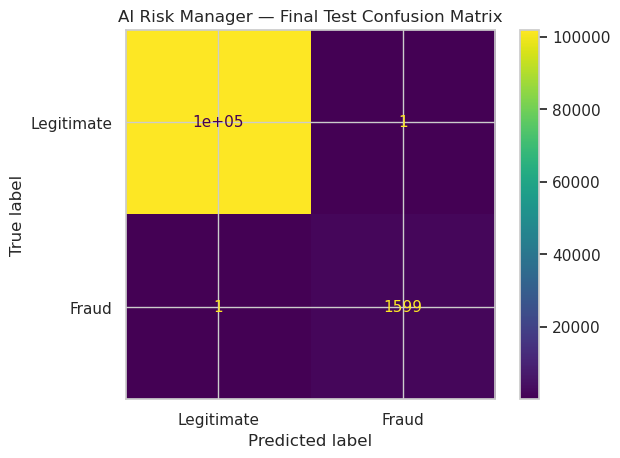

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title("AI Risk Manager — Final Test Confusion Matrix")
plt.show()

In [83]:
# ============================================================
# BUSINESS IMPACT
# ============================================================

test_business = df.loc[
    X_test.index,
    ["amount", "isFraud"]
].copy()

test_business["risk_score"] = test_prob
test_business["prediction"] = test_pred

test_business["decision"] = np.where(
    test_business["prediction"] == 1,
    "BLOCK / INVESTIGATE",
    "APPROVE"
)

display(test_business.head())

,amount,isFraud,risk_score,prediction,decision
6259047,115.00,0,0.00,0,APPROVE
6259048,"23,302.85",0,0.00,0,APPROVE
6259049,"2,180.34",0,0.00,0,APPROVE
6259050,"1,504.97",0,0.00,0,APPROVE
6259051,"4,445.60",0,0.00,0,APPROVE


In [84]:
# Actual fraud amount
actual_fraud_amount = test_business.loc[
    test_business["isFraud"] == 1,
    "amount"
].sum()

# Fraud amount successfully detected
detected_fraud_amount = test_business.loc[
    (test_business["isFraud"] == 1) &
    (test_business["prediction"] == 1),
    "amount"
].sum()

# Fraud amount missed
missed_fraud_amount = test_business.loc[
    (test_business["isFraud"] == 1) &
    (test_business["prediction"] == 0),
    "amount"
].sum()

# Legitimate transactions incorrectly flagged
false_positive_count = (
    (test_business["isFraud"] == 0) &
    (test_business["prediction"] == 1)
).sum()

print("=" * 50)
print("BUSINESS IMPACT")
print("=" * 50)

print(f"Actual fraud amount:       ₹{actual_fraud_amount:,.2f}")
print(f"Fraud amount detected:     ₹{detected_fraud_amount:,.2f}")
print(f"Fraud amount missed:       ₹{missed_fraud_amount:,.2f}")
print(f"False-positive count:      {false_positive_count:,}")

BUSINESS IMPACT
Actual fraud amount:       ₹2,658,440,348.08
Fraud amount detected:     ₹2,658,041,303.00
Fraud amount missed:       ₹399,045.08
False-positive count:      1


In [85]:
fraud_capture_rate = (
    detected_fraud_amount /
    actual_fraud_amount
)

print(
    f"Fraud amount capture rate: "
    f"{fraud_capture_rate:.2%}"
)

Fraud amount capture rate: 99.98%


In [86]:
# ============================================================
# FINAL RISK REPORT
# ============================================================

risk_report = pd.DataFrame({
    "Metric": [
        "Model",
        "Risk Threshold",
        "Test Transactions",
        "Actual Fraud Transactions",
        "Predicted Fraud Transactions",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positives",
        "False Negatives",
        "Actual Fraud Amount",
        "Detected Fraud Amount",
        "Missed Fraud Amount",
        "Fraud Amount Capture Rate"
    ],

    "Value": [
        "Gradient Boosting",
        RISK_THRESHOLD,
        len(y_test),
        int(y_test.sum()),
        int(test_pred.sum()),
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        int(fp),
        int(fn),
        f"₹{actual_fraud_amount:,.2f}",
        f"₹{detected_fraud_amount:,.2f}",
        f"₹{missed_fraud_amount:,.2f}",
        f"{fraud_capture_rate:.2%}"
    ]
})

display(risk_report)

,Metric,Value
0,Model,Gradient Boosting
1,Risk Threshold,0.70
2,Test Transactions,103573
3,Actual Fraud Transactions,1600
4,Predicted Fraud Transactions,1600
5,Precision,0.9994
6,Recall,0.9994
7,F1 Score,0.9994
8,False Positives,1
9,False Negatives,1


In [87]:
# ============================================================
# SINGLE TRANSACTION RISK SCORER
# ============================================================

def assess_transaction(model, transaction_features):

    probability = model.predict_proba(
        transaction_features
    )[0, 1]

    return {
        "risk_score": round(float(probability), 4),
        "risk_level": risk_level(probability),
        "decision": make_decision(probability)
    }

In [88]:
result = assess_transaction(
    final_model,
    X_test.iloc[[0]]
)

print(result)

{'risk_score': 0.0001, 'risk_level': 'LOW', 'decision': 'APPROVE'}
